# 05-Finance Tutorial-Pricing Bull Spreads
### Modified for Quantum Rings toolkit for Qiskit 2.x

In [1]:
# This tutorial is from:
#https://qiskit-community.github.io/qiskit-finance/tutorials/05_bull_spread_pricing.html

# Modified for use with Quantum Rings toolkit

In [2]:
#
# Setup your account
# You can also save your account locally using the class method QrRuntimeService.save_account(...) and
# invoke the QrRuntimeService class constructor without any arguments.
#
import os
my_token = os.environ["QR_TOKEN"]
my_name = os.environ["QR_ACCOUNT"]

#
# Set the backend of your choice, depending upon the task and your hardware configuration.
# See SDK documentation for additional help.
#

my_backend = "scarlet_quantum_rings"

In [3]:
import matplotlib.pyplot as plt

%matplotlib inline
import numpy as np

from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem
from qiskit.circuit.library import LinearAmplitudeFunction
#from qiskit_aer.primitives import Sampler
from qiskit_finance.circuit.library import LogNormalDistribution

In [4]:
from quantumrings.toolkit.qiskit import QrRuntimeService
from quantumrings.toolkit.qiskit import QrSamplerV2 as Sampler

#
# Acquire Quantum Rings Backend
#

qr_services = QrRuntimeService(name = my_name, token = my_token)
qr_backend = qr_services.backend(name = my_backend, precision = "single")

In [5]:
# number of qubits to represent the uncertainty
num_uncertainty_qubits = 3

# parameters for considered random distribution
S = 2.0  # initial spot price
vol = 0.4  # volatility of 40%
r = 0.05  # annual interest rate of 4%
T = 40 / 365  # 40 days to maturity

# resulting parameters for log-normal distribution
mu = (r - 0.5 * vol**2) * T + np.log(S)
sigma = vol * np.sqrt(T)
mean = np.exp(mu + sigma**2 / 2)
variance = (np.exp(sigma**2) - 1) * np.exp(2 * mu + sigma**2)
stddev = np.sqrt(variance)

# lowest and highest value considered for the spot price; in between, an equidistant discretization is considered.
low = np.maximum(0, mean - 3 * stddev)
high = mean + 3 * stddev

# construct circuit for uncertainty model
uncertainty_model = LogNormalDistribution(
    num_uncertainty_qubits, mu=mu, sigma=sigma**2, bounds=(low, high)
)

<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\%'
C:\Users\vkasi\AppData\Local\Temp\ipykernel_23904\2885665035.py:8: SyntaxWarning: invalid escape sequence '\$'
  plt.xlabel("Spot Price at Maturity $S_T$ (\$)", size=15)
C:\Users\vkasi\AppData\Local\Temp\ipykernel_23904\2885665035.py:9: SyntaxWarning: invalid escape sequence '\%'
  plt.ylabel("Probability ($\%$)", size=15)


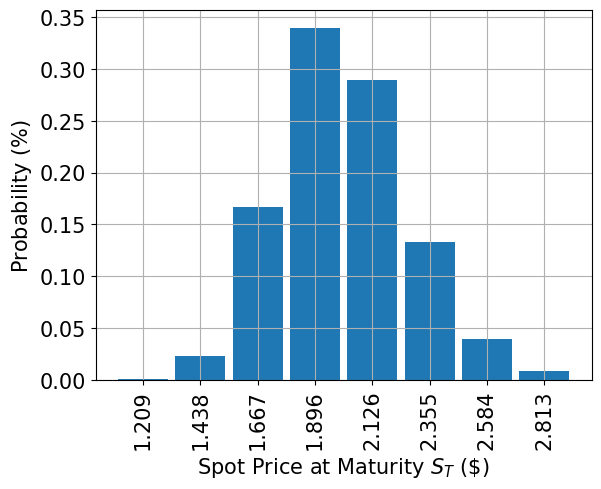

In [6]:
# plot probability distribution
x = uncertainty_model.values
y = uncertainty_model.probabilities
plt.bar(x, y, width=0.2)
plt.xticks(x, size=15, rotation=90)
plt.yticks(size=15)
plt.grid()
plt.xlabel("Spot Price at Maturity $S_T$ (\$)", size=15)
plt.ylabel("Probability ($\%$)", size=15)
plt.show()

In [7]:
# set the strike price (should be within the low and the high value of the uncertainty)
strike_price_1 = 1.438
strike_price_2 = 2.584

# set the approximation scaling for the payoff function
rescaling_factor = 0.25

# setup piecewise linear objective fcuntion
breakpoints = [low, strike_price_1, strike_price_2]
slopes = [0, 1, 0]
offsets = [0, 0, strike_price_2 - strike_price_1]
f_min = 0
f_max = strike_price_2 - strike_price_1
bull_spread_objective = LinearAmplitudeFunction(
    num_uncertainty_qubits,
    slopes,
    offsets,
    domain=(low, high),
    image=(f_min, f_max),
    breakpoints=breakpoints,
    rescaling_factor=rescaling_factor,
)

# construct A operator for QAE for the payoff function by
# composing the uncertainty model and the objective
bull_spread = bull_spread_objective.compose(uncertainty_model, front=True)

C:\Users\vkasi\AppData\Local\Temp\ipykernel_23904\1515371662.py:14: DeprecationWarning: The class ``qiskit.circuit.library.arithmetic.linear_amplitude_function.LinearAmplitudeFunction`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.LinearAmplitudeFunctionGate instead.
  bull_spread_objective = LinearAmplitudeFunction(


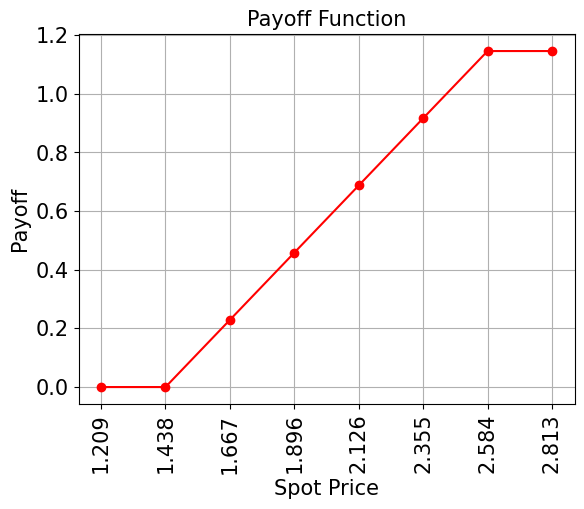

In [8]:
# plot exact payoff function (evaluated on the grid of the uncertainty model)
x = uncertainty_model.values
y = np.minimum(np.maximum(0, x - strike_price_1), strike_price_2 - strike_price_1)
plt.plot(x, y, "ro-")
plt.grid()
plt.title("Payoff Function", size=15)
plt.xlabel("Spot Price", size=15)
plt.ylabel("Payoff", size=15)
plt.xticks(x, size=15, rotation=90)
plt.yticks(size=15)
plt.show()


In [9]:
# evaluate exact expected value (normalized to the [0, 1] interval)
exact_value = np.dot(uncertainty_model.probabilities, y)
exact_delta = sum(
    uncertainty_model.probabilities[np.logical_and(x >= strike_price_1, x <= strike_price_2)]
)
print("exact expected value:\t%.4f" % exact_value)
print("exact delta value:   \t%.4f" % exact_delta)

exact expected value:	0.5695
exact delta value:   	0.9291


In [10]:
# set target precision and confidence level
epsilon = 0.01
alpha = 0.05

problem = EstimationProblem(
    state_preparation=bull_spread,
    objective_qubits=[num_uncertainty_qubits],
    post_processing=bull_spread_objective.post_processing,
)
# construct amplitude estimation
ae = IterativeAmplitudeEstimation(
    epsilon_target=epsilon, alpha=alpha, sampler=Sampler(backend=qr_backend,options={"shots": 100, "seed": 75})
)

In [11]:
result = ae.estimate(problem)

In [12]:
conf_int = np.array(result.confidence_interval_processed)
print("Exact value:    \t%.4f" % exact_value)
print("Estimated value:\t%.4f" % result.estimation_processed)
print("Confidence interval: \t[%.4f, %.4f]" % tuple(conf_int))

Exact value:    	0.5695
Estimated value:	0.5628
Confidence interval: 	[0.5391, 0.5866]


In [13]:
# Example output:

#Exact value:    	0.5695
#Estimated value:	0.5815
#Confidence interval: 	[0.5577, 0.6052]

In [14]:
# setup piecewise linear objective fcuntion
breakpoints = [low, strike_price_1, strike_price_2]
slopes = [0, 0, 0]
offsets = [0, 1, 0]
f_min = 0
f_max = 1

bull_spread_delta_objective = LinearAmplitudeFunction(
    num_uncertainty_qubits,
    slopes,
    offsets,
    domain=(low, high),
    image=(f_min, f_max),
    breakpoints=breakpoints,
)  # no approximation necessary, hence no rescaling factor

# construct the A operator by stacking the uncertainty model and payoff function together
bull_spread_delta = bull_spread_delta_objective.compose(uncertainty_model, front=True)

C:\Users\vkasi\AppData\Local\Temp\ipykernel_23904\1368781336.py:8: DeprecationWarning: The class ``qiskit.circuit.library.arithmetic.linear_amplitude_function.LinearAmplitudeFunction`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.LinearAmplitudeFunctionGate instead.
  bull_spread_delta_objective = LinearAmplitudeFunction(


In [15]:
# set target precision and confidence level
epsilon = 0.01
alpha = 0.05

problem = EstimationProblem(
    state_preparation=bull_spread_delta, objective_qubits=[num_uncertainty_qubits]
)
# construct amplitude estimation
ae_delta = IterativeAmplitudeEstimation(
    epsilon_target=epsilon, alpha=alpha, sampler=Sampler(backend = qr_backend, options={"shots": 100, "seed": 75})
)

In [16]:
result_delta = ae_delta.estimate(problem)

In [17]:
conf_int = np.array(result_delta.confidence_interval)
print("Exact delta:    \t%.4f" % exact_delta)
print("Estimated value:\t%.4f" % result_delta.estimation)
print("Confidence interval: \t[%.4f, %.4f]" % tuple(conf_int))

Exact delta:    	0.9291
Estimated value:	0.9299
Confidence interval: 	[0.9252, 0.9346]


In [18]:
# Example output:

# Exact delta:    	0.9291
# Estimated value:	0.9289
# Confidence interval: 	[0.9242, 0.9336]

In [19]:
import tutorial_magics

%qiskit_version_table
%quantumrings_version_table
%qiskit_copyright

Software,Version
QuantumRingsLib,0.11.0
quantumrings-toolkit-qiskit,0.1.10
